data.rename(columns={
    "What best describes the place you grew up in? ": "Place_Grew_Up",
    "When considering a purchase, how important are the following factors to you?  [Price/Cost]": "Price_Importance",
    "When considering a purchase, how important are the following factors to you?  [Brand reputation]": "Brand_Importance",
    "When considering a purchase, how important are the following factors to you?  [Peer recommendation]": "Peer_Importance",
    "When considering a purchase, how important are the following factors to you?  [Long-term utility/value]": "Utility_Importance"
}, inplace=True)


data.rename(columns={
    "How do you track your monthly expenditures? ": "Track_Expenditures",
    "What is the expected graph for your expenditure for the months ": "Expenditure_Graph"
}, inplace=True)


data.rename(columns={
    "In which of the following scenarios would you justify an unexpected expense of ₹1,500 or more?": "Justify_Unexpected_Expense"
}, inplace=True)

data.rename(columns={
    "How often do you make purchases that you hadn’t planned for? ": "Unplanned_Purchases",
    "On average, how much do you spend per month (excluding tuition fees)? ": "Monthly_Spend",
    "On a scale of 1 to 5, how much do social events or peer pressure influence your spending? ": "Peer_Influence",
    "How confident do you feel in your ability to manage your personal finances? ": "Finance_Confidence"
}, inplace=True)

data.rename(columns={
    "In which categories do you spend the majority of your budget?  [Food & Dining]": "Budget_FoodDining",
    "In which categories do you spend the majority of your budget?  [Travel]": "Budget_Travel",
    "In which categories do you spend the majority of your budget?  [Fashion]": "Budget_Fashion",
    "In which categories do you spend the majority of your budget?  [Subscriptions (Netflix, Spotify, etc.)]": "Budget_Subscriptions",
    "In which categories do you spend the majority of your budget?  [Fun & Entertainment]": "Budget_Entertainment"
}, inplace=True)


In [11]:
# it still has some issues

import pandas as pd

data = pd.read_csv('../Dataset/Scored_Cleaned_Data.csv')

In [12]:
import numpy as np
import pandas as pd
from pyclustering.cluster.kmedoids import kmedoids
from sklearn.metrics import silhouette_score
from sklearn.model_selection import KFold

def evaluate_kmedoids_custom_logic(df, target_col='Risk_score', n_folds=5):
    X_df = df.drop(columns=["Timestamp", "Group"], errors='ignore')
    spend_values = df[target_col].values
    
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    overall_results = []

    print(f"{'K':<5} | {'Avg Silhouette':<15} | {'Custom Deviation':<20}")
    print("-" * 50)

    for k in range(3, 20):
        fold_silhouettes = []
        fold_custom_deviations = []
        
        for train_idx, val_idx in kf.split(X_df):
            X_fold_list = X_df.iloc[train_idx].values.tolist()
            spend_fold = spend_values[train_idx]
            
            # Fit K-Medoids
            initial_indices = np.random.choice(len(X_fold_list), k, replace=False).tolist()
            kmed_instance = kmedoids(X_fold_list, initial_indices)
            kmed_instance.process()
            clusters_indices = kmed_instance.get_clusters()
            
            # Extract labels
            labels = np.zeros(len(X_fold_list), dtype=int)
            for cluster_id, indices in enumerate(clusters_indices):
                for idx in indices:
                    labels[idx] = cluster_id

            # Silhouette
            sil = silhouette_score(X_fold_list, labels)
            fold_silhouettes.append(sil)

            # (sum(|M - means|^0.5))^2
            cluster_means = [spend_fold[idx_list].mean() for idx_list in clusters_indices if len(idx_list) > 0]
            c_means = np.array(cluster_means)
            M = np.mean(c_means)
            diffs = np.abs(M - c_means)
            custom_dev = (np.sum(diffs**0.5))**2
            fold_custom_deviations.append(custom_dev)

        avg_sil = np.mean(fold_silhouettes)
        avg_dev = np.mean(fold_custom_deviations)
        overall_results.append({'k': k, 'Silhouette': avg_sil, 'Custom_Deviation': avg_dev})
        print(f"{k:<5} | {avg_sil:<15.4f} | {avg_dev:<20.2f}")

    return pd.DataFrame(overall_results)

kmedoids_custom_results = evaluate_kmedoids_custom_logic(data)

K     | Avg Silhouette  | Custom Deviation    
--------------------------------------------------
3     | 0.4795          | 9.13                
4     | 0.4169          | 31.61               
5     | 0.3773          | 99.18               
6     | 0.3719          | 365.63              
7     | 0.3569          | 750.50              
8     | 0.3636          | 1390.64             
9     | 0.3740          | 2109.58             
10    | 0.3720          | 2837.57             
11    | 0.3911          | 3757.38             
12    | 0.4066          | 4771.24             
13    | 0.4045          | 5615.06             
14    | 0.4078          | 5815.31             
15    | 0.4222          | 6929.56             
16    | 0.4326          | 7977.54             
17    | 0.4505          | 8263.44             
18    | 0.4722          | 9254.96             
19    | 0.4766          | 9730.41             


In [13]:
import numpy as np
import pandas as pd
from pyclustering.cluster.kmedoids import kmedoids
from sklearn.metrics import normalized_mutual_info_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Pre-process the full dataset (Encoding + Scaling)
# PCA/K-Medoids require numeric data, so we encode first
X_optimized = data.drop(columns=['Timestamp', 'Group',"Place_Grew_Up","Unnamed: 0","Price_Importance","Peer_Importance "], errors='ignore').copy()

for col in X_optimized.columns:
    if not pd.api.types.is_numeric_dtype(X_optimized[col]):
        X_optimized[col] = LabelEncoder().fit_transform(X_optimized[col].astype(str))

y_true = data['Group'].values
optimal_k = 7  # Set this to your best K from the evaluation results

def get_kmedoids_nmi(df_input):
    # Scale current feature set
    X_scaled = StandardScaler().fit_transform(df_input)
    X_list = X_scaled.tolist()
    
    # Initialize and fit
    initial_indices = np.random.choice(len(X_list), optimal_k, replace=False).tolist()
    kmed = kmedoids(X_list, initial_indices)
    kmed.process()
    
    # Extract labels
    clusters = kmed.get_clusters()
    labels = np.zeros(len(X_list))
    for cluster_id, indices in enumerate(clusters):
        for idx in indices:
            labels[idx] = cluster_id
            
    return normalized_mutual_info_score(y_true, labels)

# 2. Baseline
baseline_nmi = get_kmedoids_nmi(X_optimized)
print(f"📊 K-MEDOIDS BASELINE NMI: {baseline_nmi:.4f}")
print("-" * 60)

kmedoids_results = []

# 3. Optimization Loop
for col in X_optimized.columns:
    X_temp = X_optimized.drop(columns=[col])
    current_nmi = get_kmedoids_nmi(X_temp)
    
    improvement = current_nmi - baseline_nmi
    status = "⭐ NOISE (Drop)" if improvement > 0 else "KEEP"
    
    print(f"Dropped: {col:<25} | NMI: {current_nmi:.4f} | {status}")
    
    kmedoids_results.append({
        "Removed": col,
        "NMI": current_nmi,
        "Change": improvement
    })

# 4. Final Ranking
rank_df = pd.DataFrame(kmedoids_results).sort_values(by="NMI", ascending=False)
print("\n--- Top Features contributing to the Curse of Dimensionality ---")
print(rank_df.head(5))

📊 K-MEDOIDS BASELINE NMI: 0.2303
------------------------------------------------------------
Dropped: Brand_Importance          | NMI: 0.2161 | KEEP
Dropped: Peer_Importance           | NMI: 0.2212 | KEEP
Dropped: Utility_Importance        | NMI: 0.2488 | ⭐ NOISE (Drop)
Dropped: Track_Bank_Balance        | NMI: 0.1799 | KEEP
Dropped: Track_None                | NMI: 0.2194 | KEEP
Dropped: Track_Payment_Apps        | NMI: 0.1995 | KEEP
Dropped: Track_Apps_Spreadsheet    | NMI: 0.1971 | KEEP
Dropped: Graph_Irregular_Random    | NMI: 0.2197 | KEEP
Dropped: Graph_Spike_Then_Low      | NMI: 0.2303 | KEEP
Dropped: Graph_High_Weekends       | NMI: 0.2286 | KEEP
Dropped: Graph_Uniform_Daily       | NMI: 0.2126 | KEEP
Dropped: Expenditure_Graph_nan     | NMI: 0.2303 | ⭐ NOISE (Drop)
Dropped: Emergency(JBS)            | NMI: 0.2303 | ⭐ NOISE (Drop)
Dropped: Discounts(JBS)            | NMI: 0.2418 | ⭐ NOISE (Drop)
Dropped: Party(JBS)                | NMI: 0.1344 | KEEP
Dropped: Workshop(JBS)    

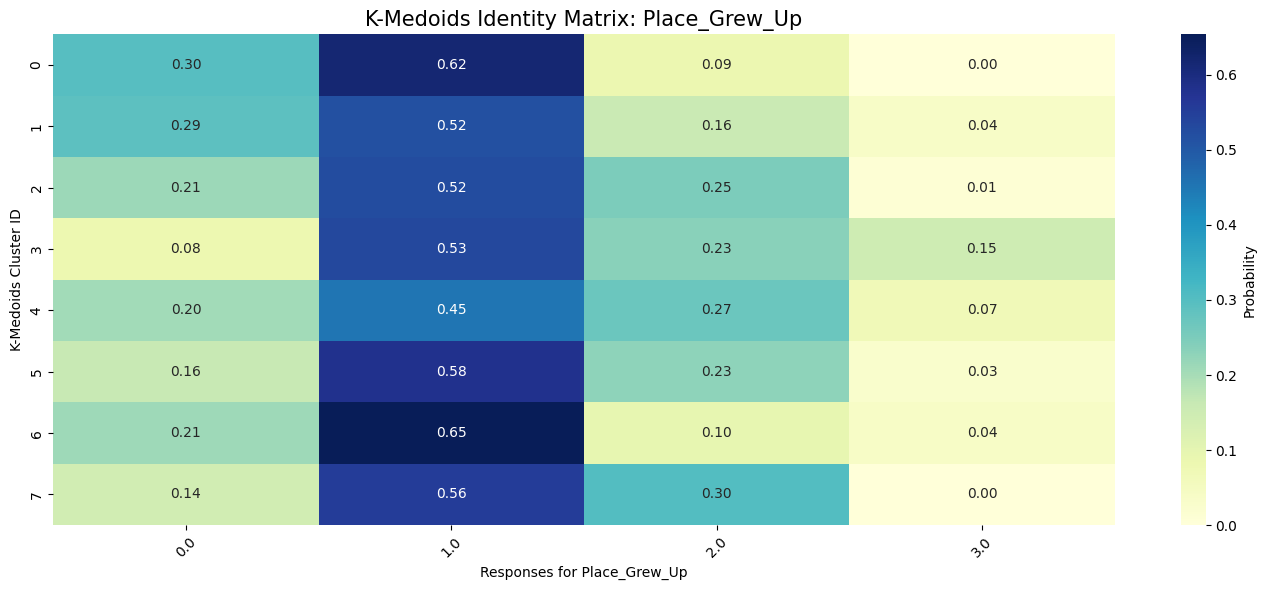

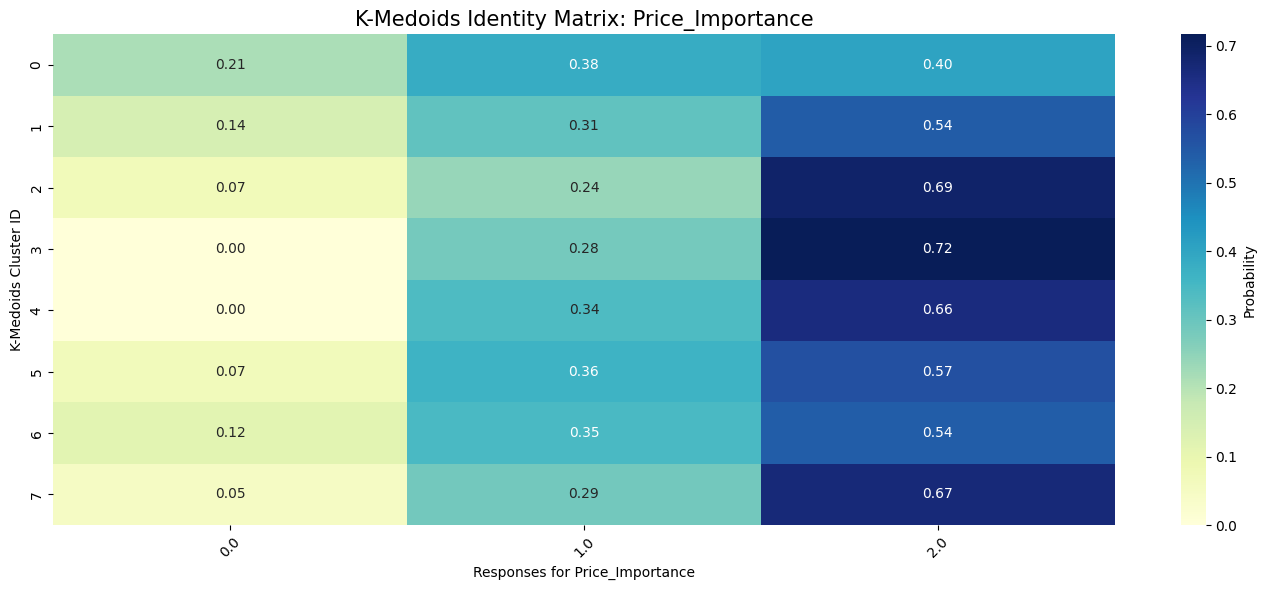

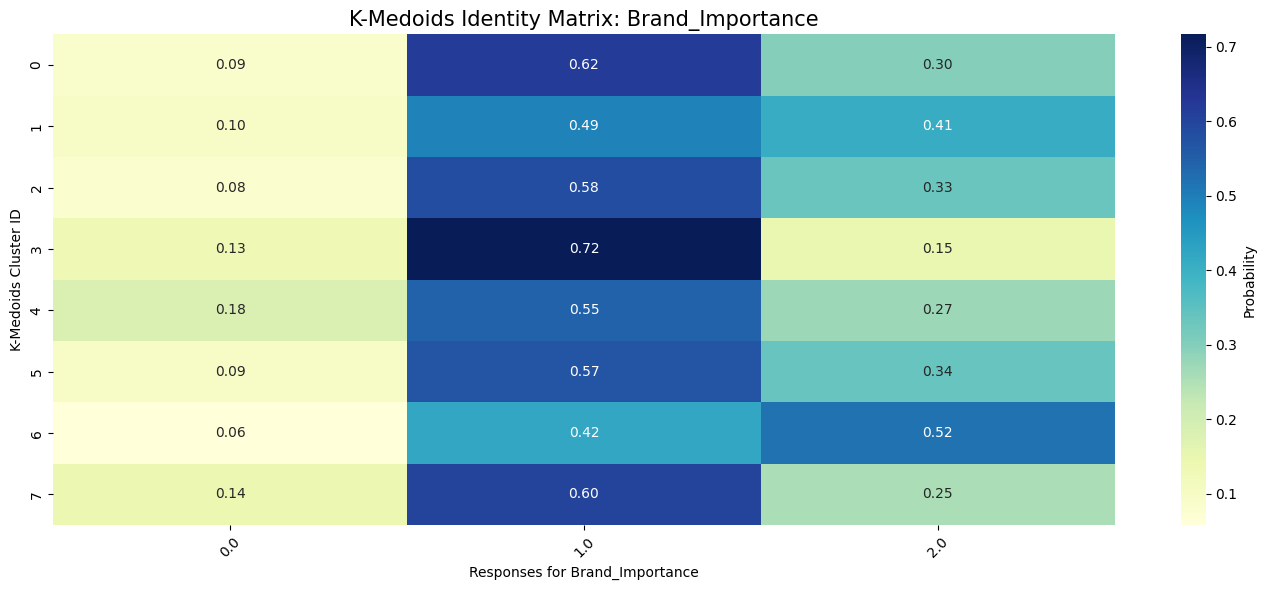

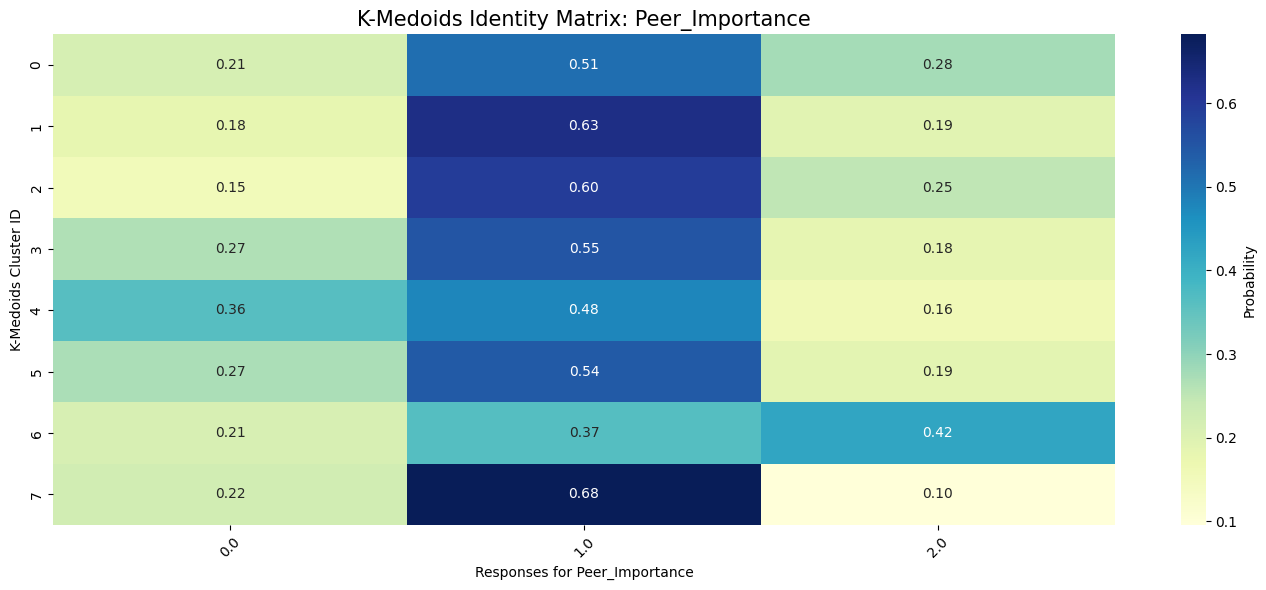

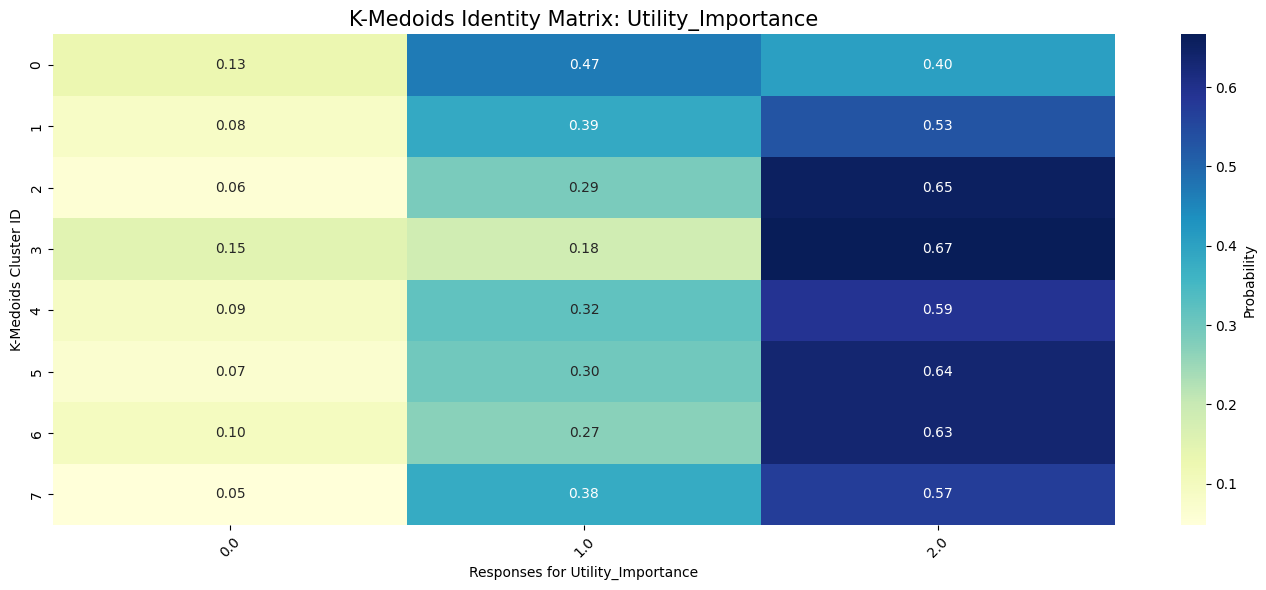

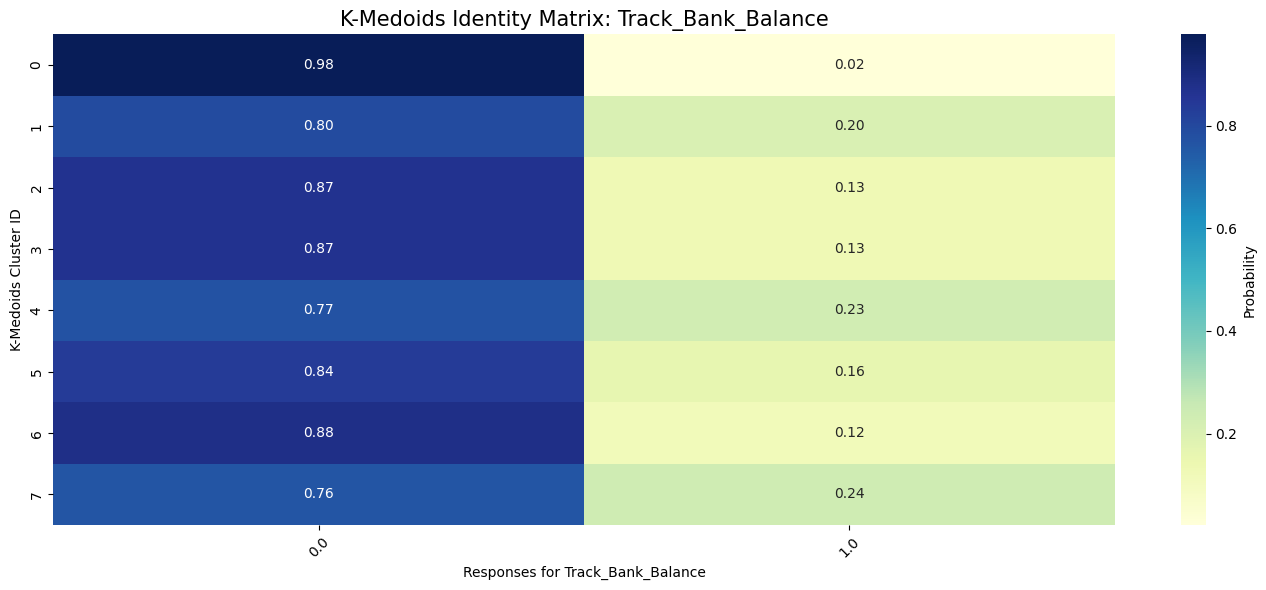

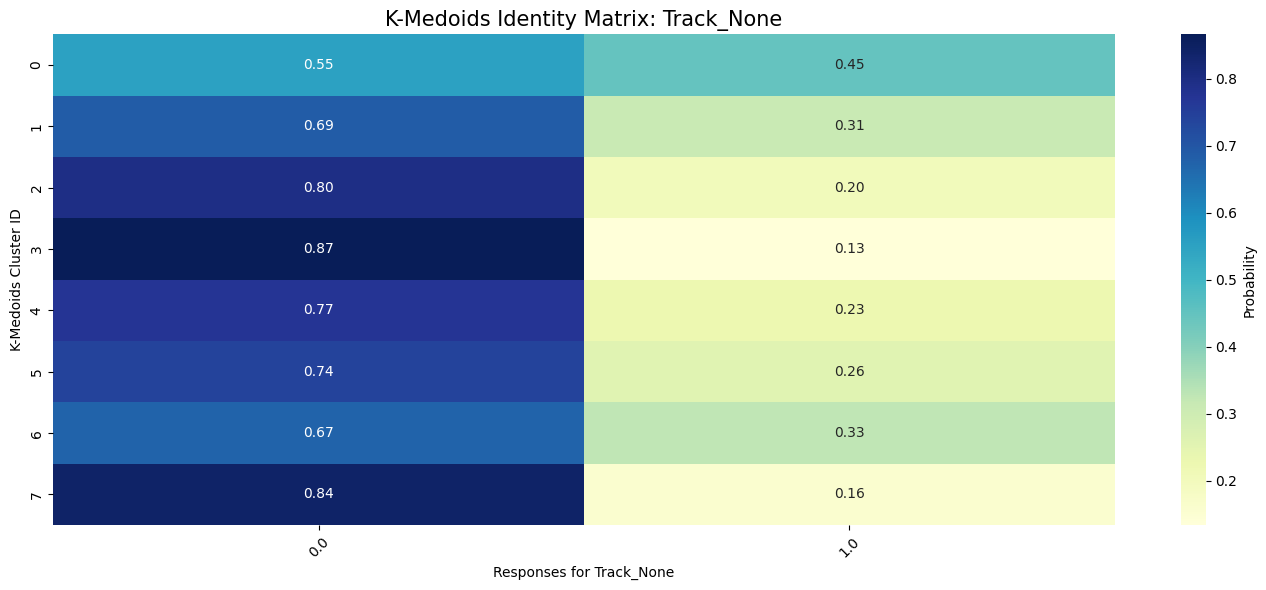

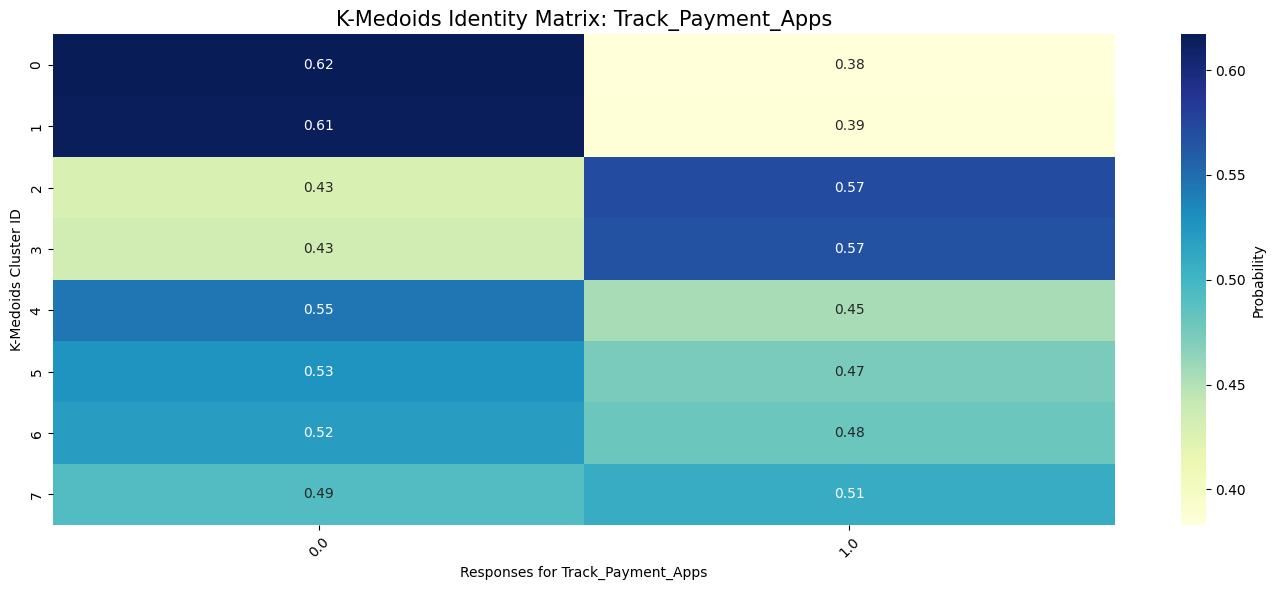

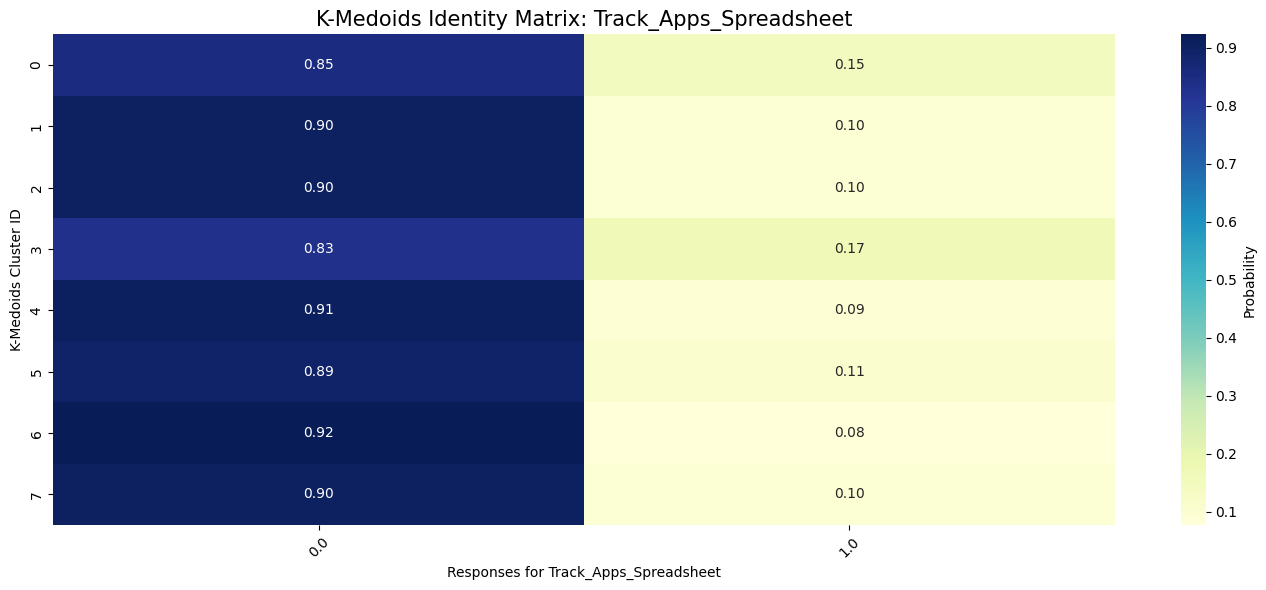

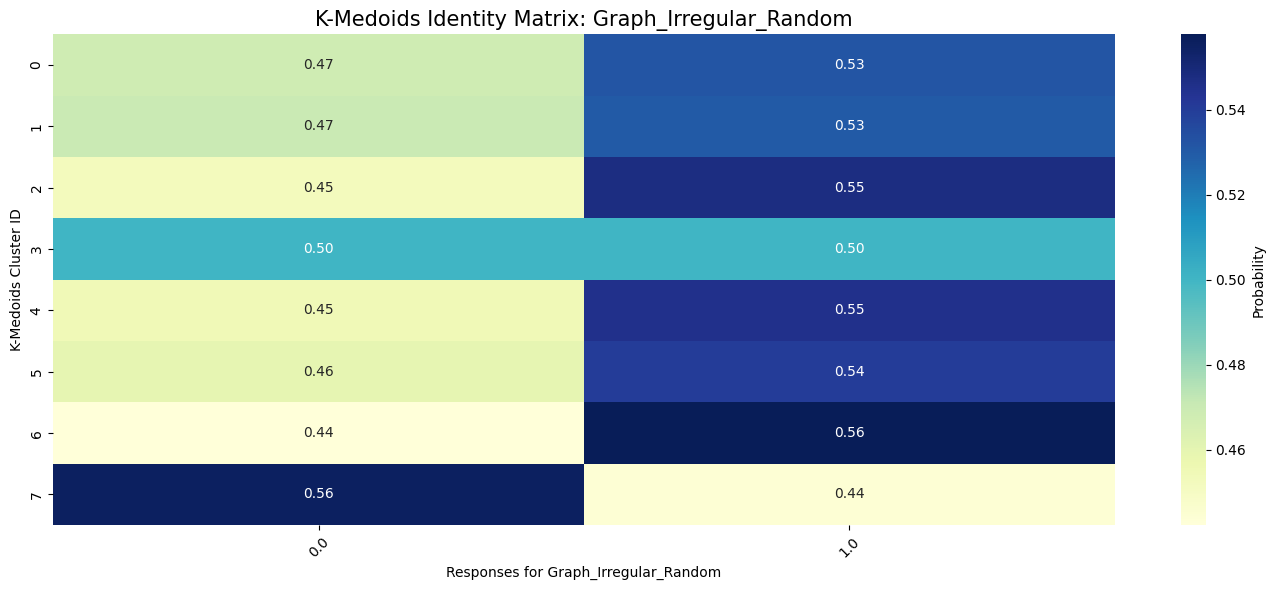

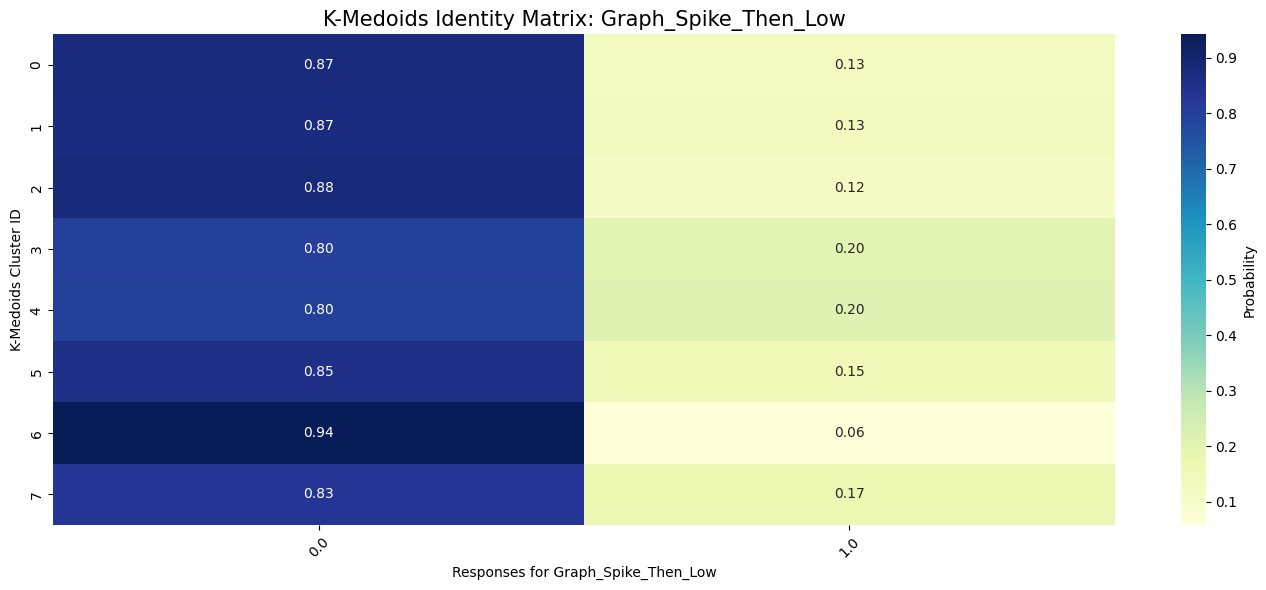

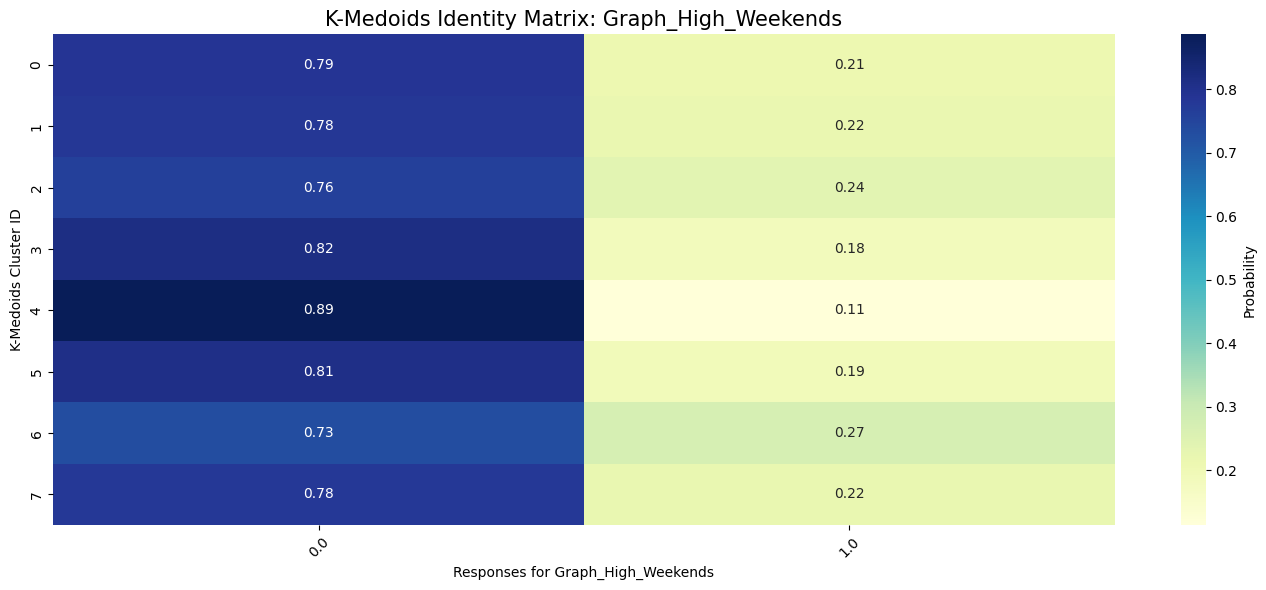

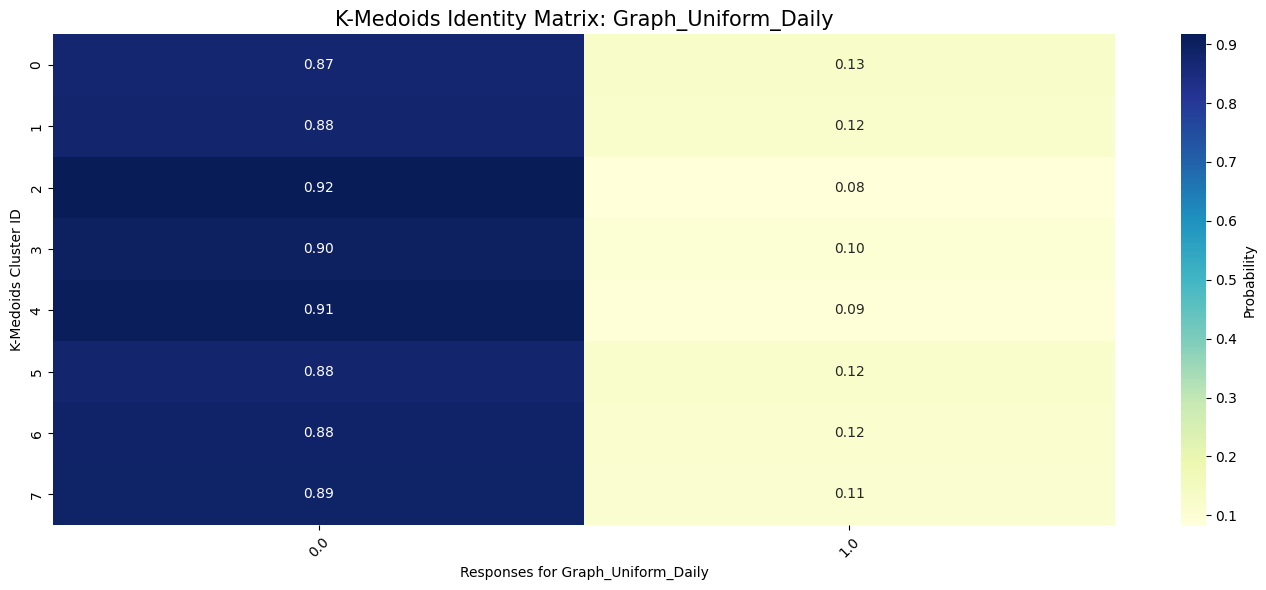

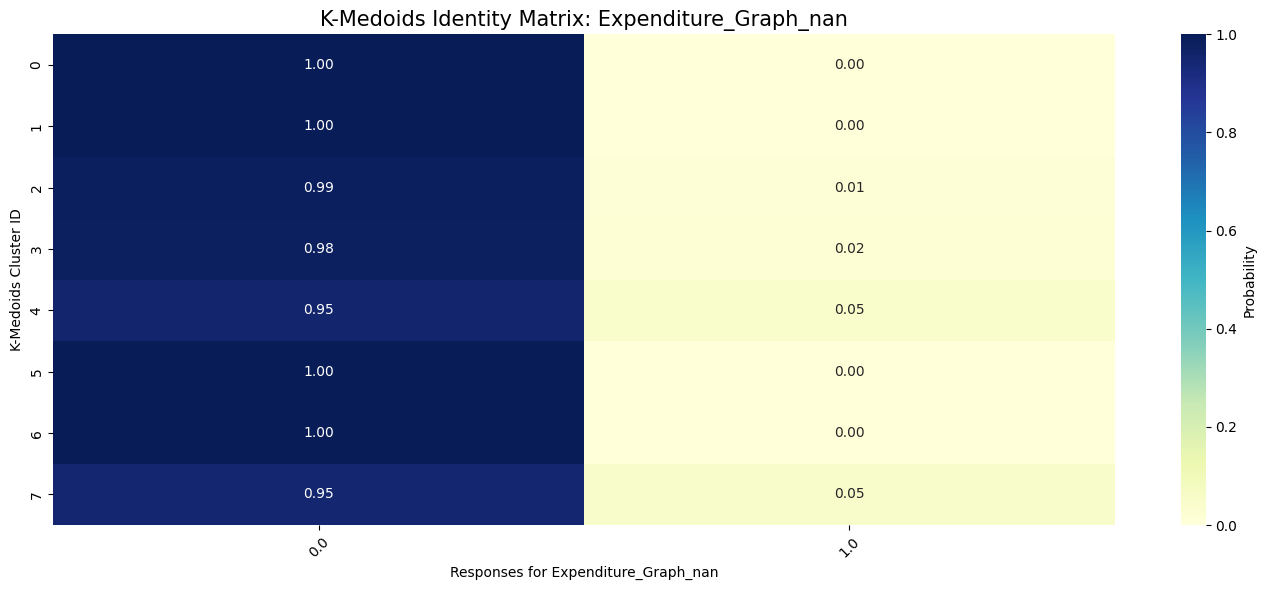

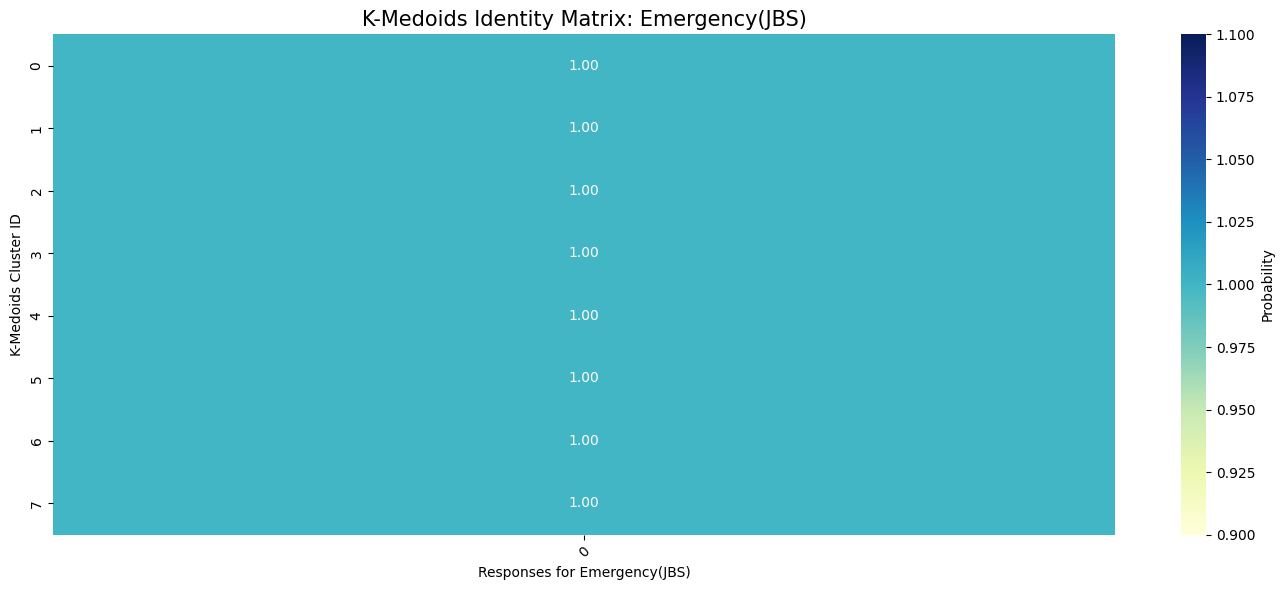

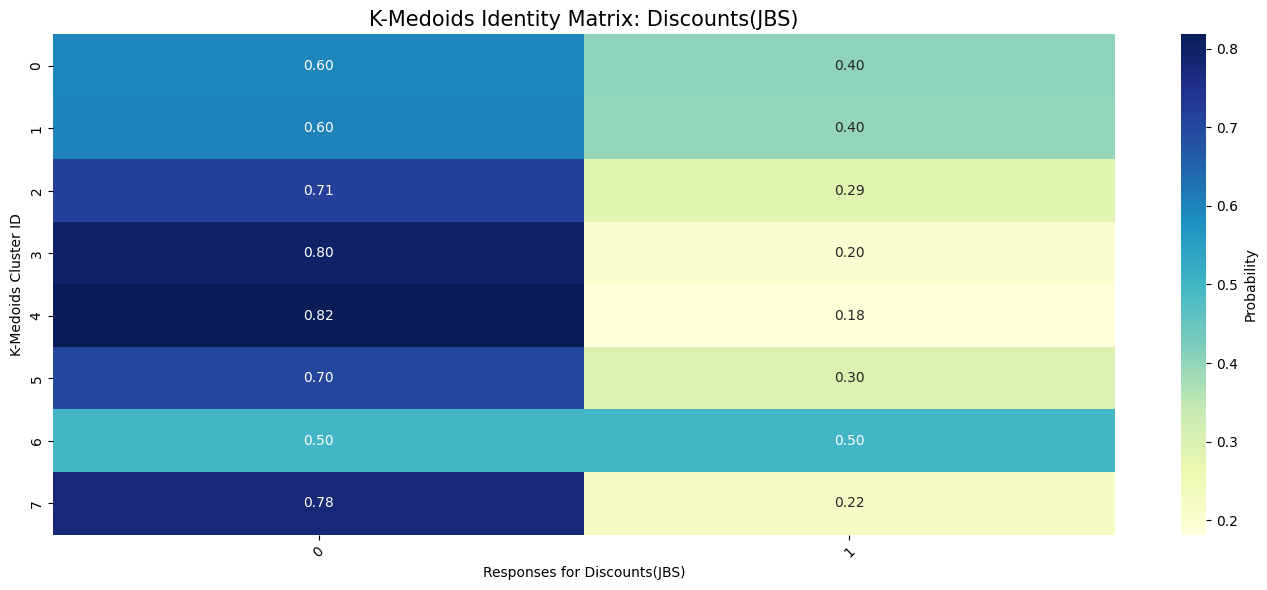

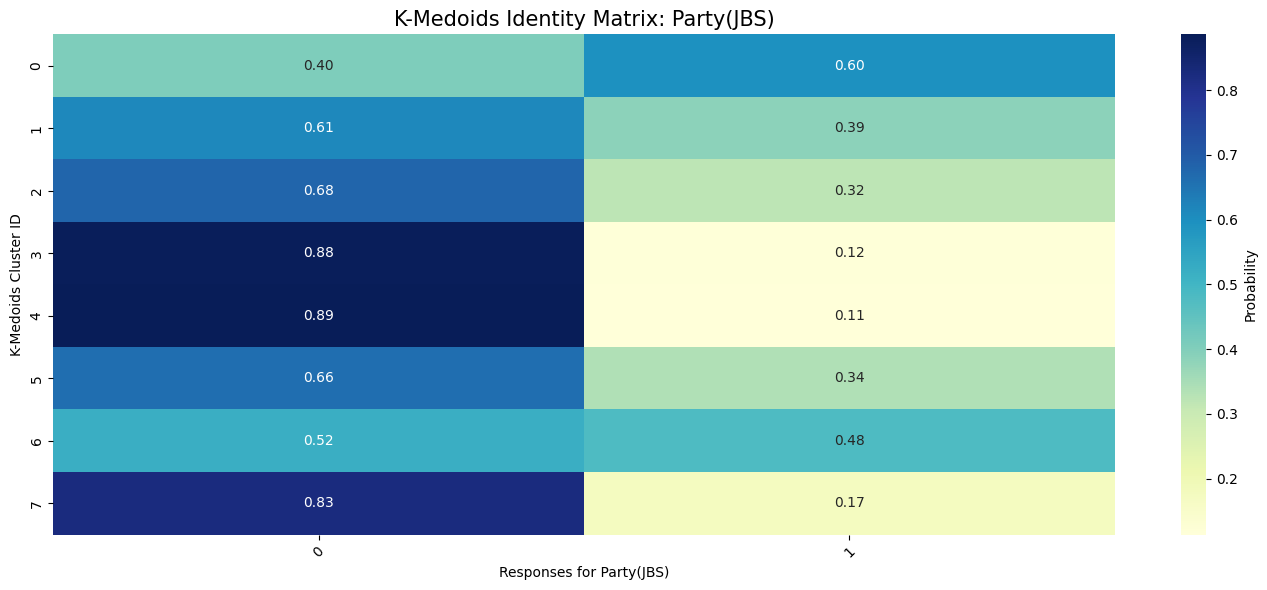

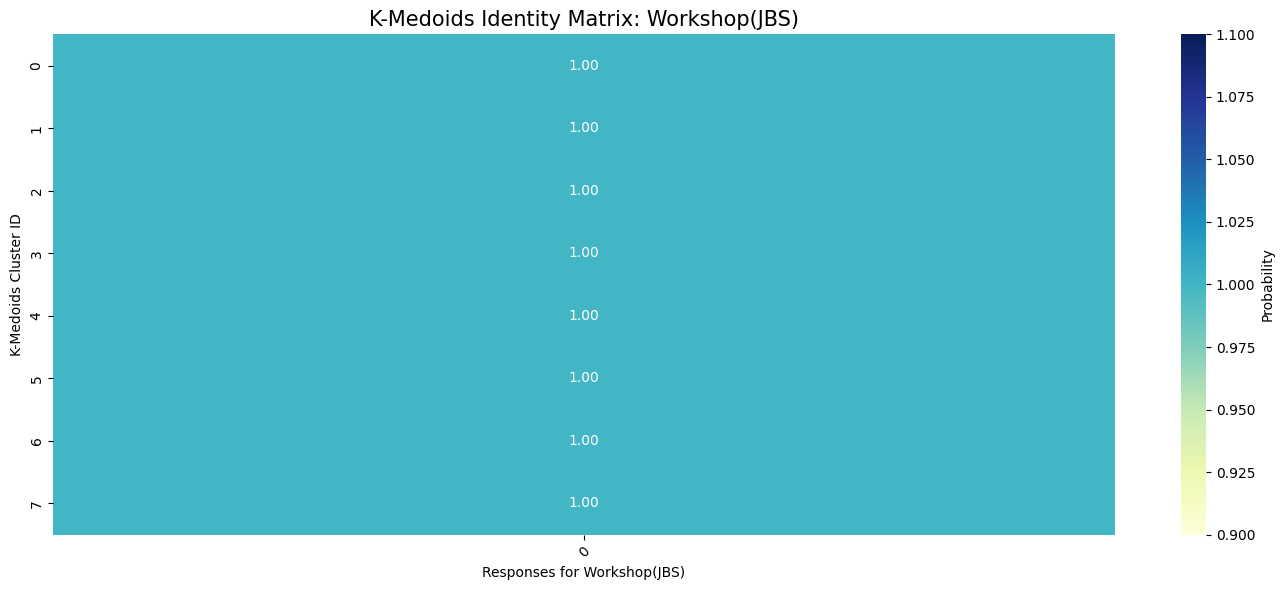

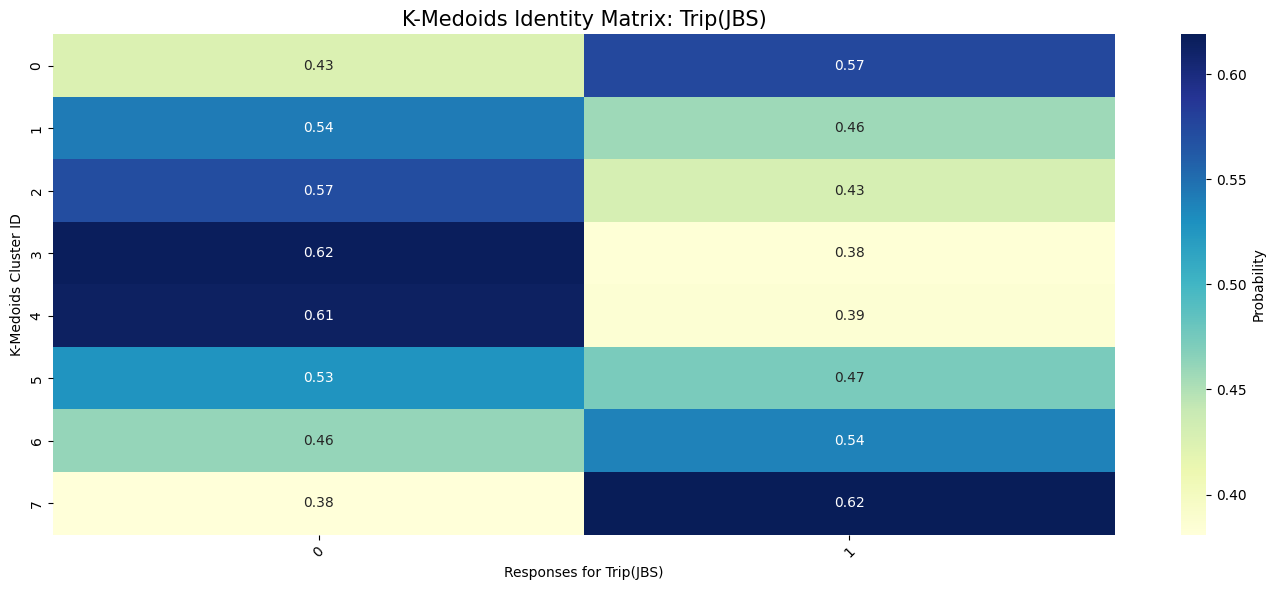

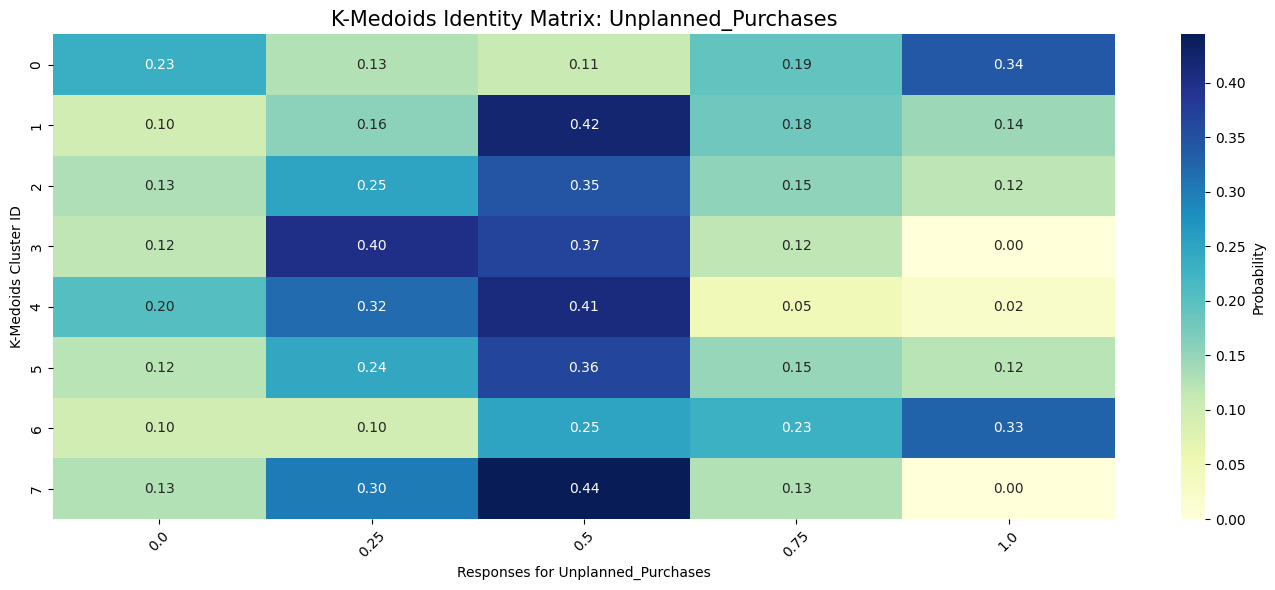

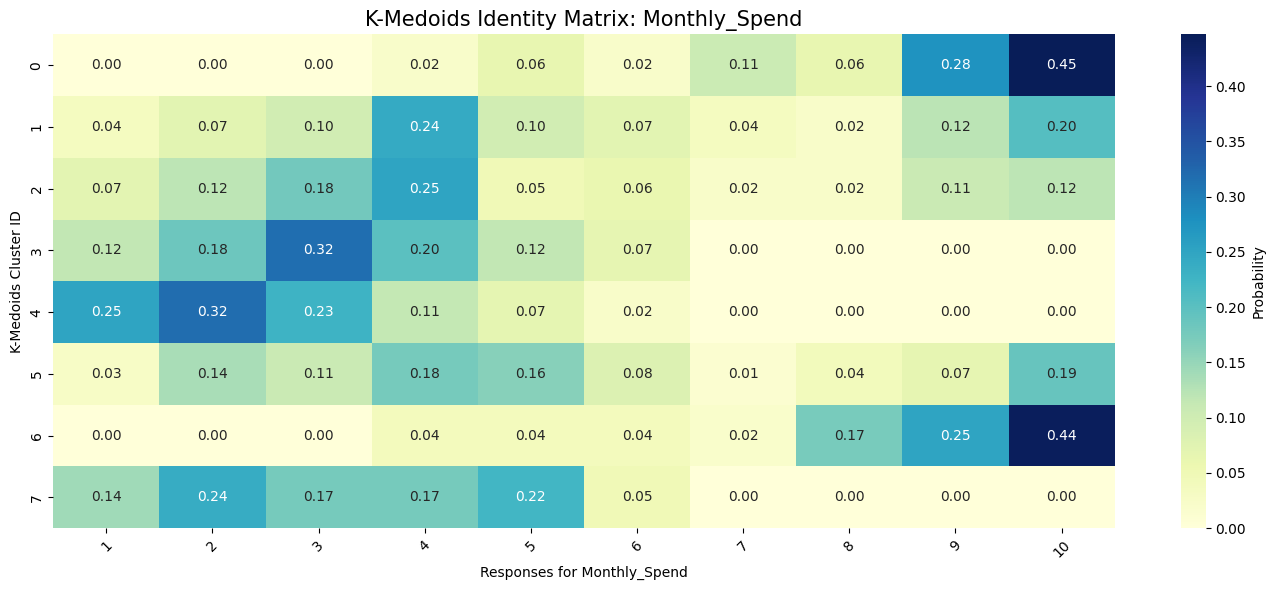

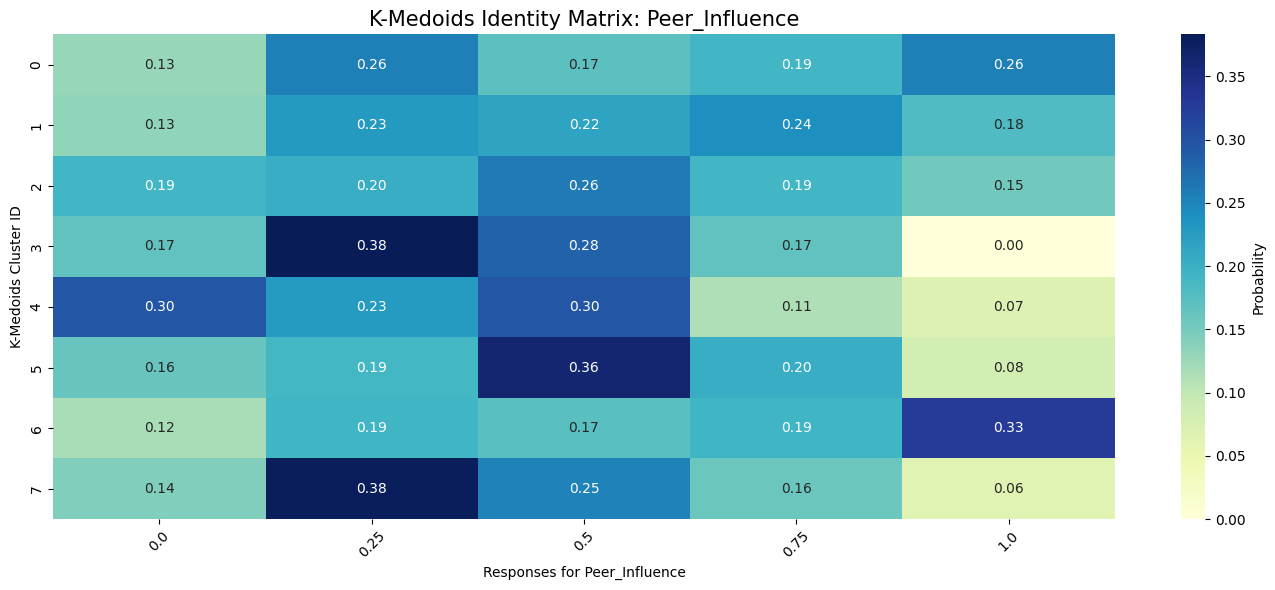

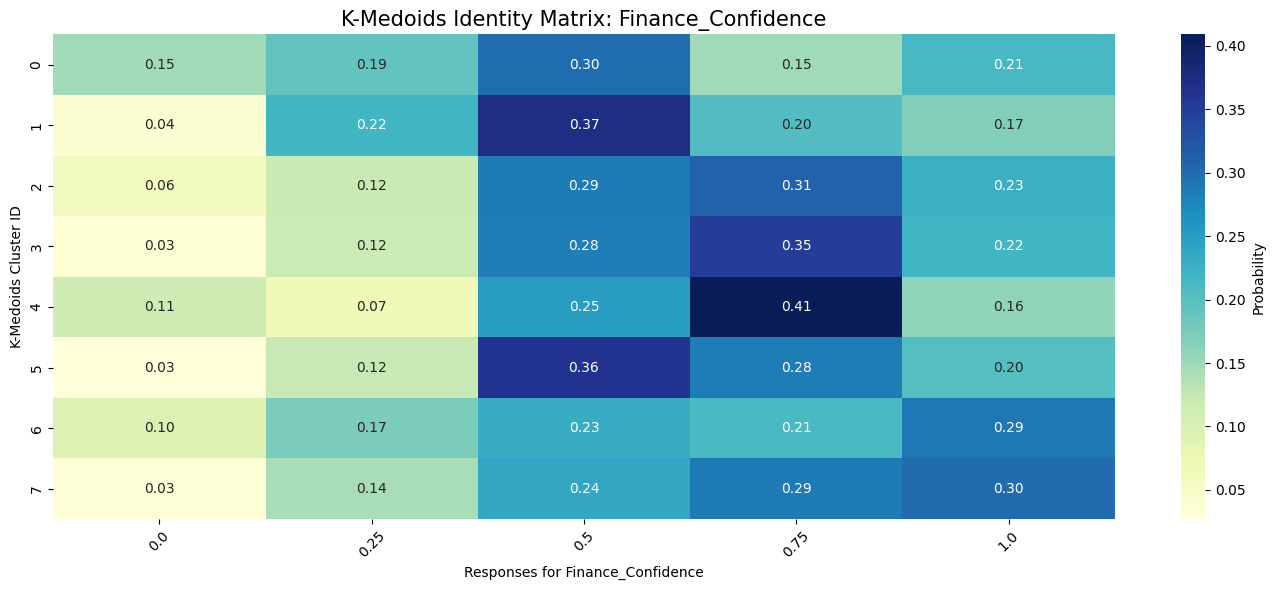

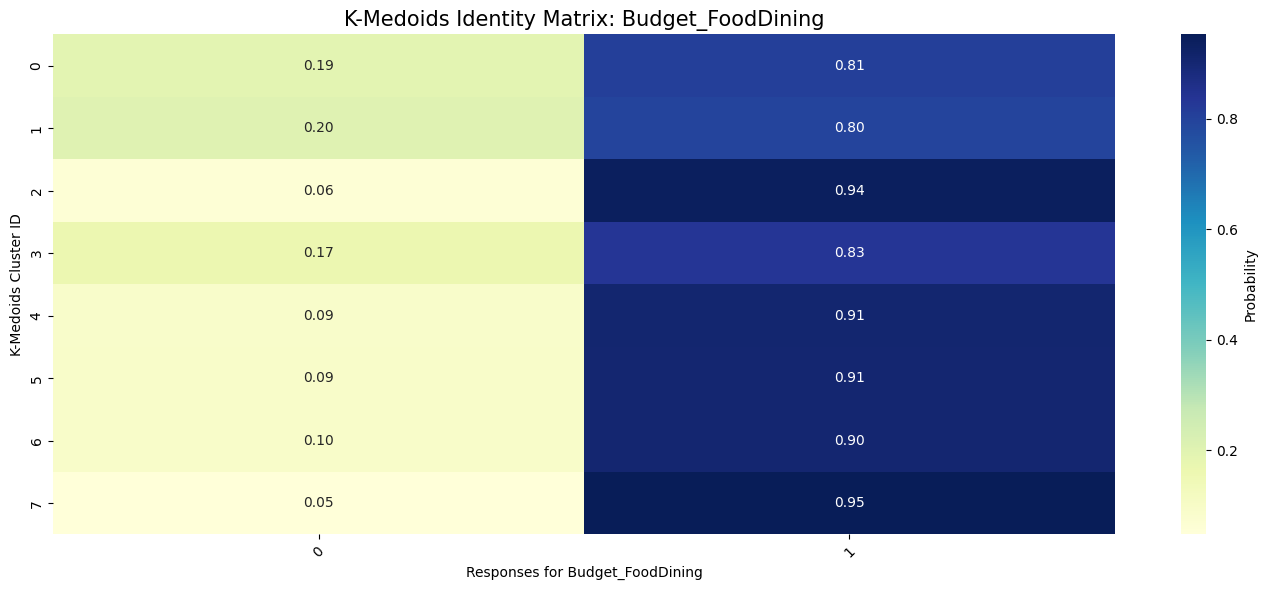

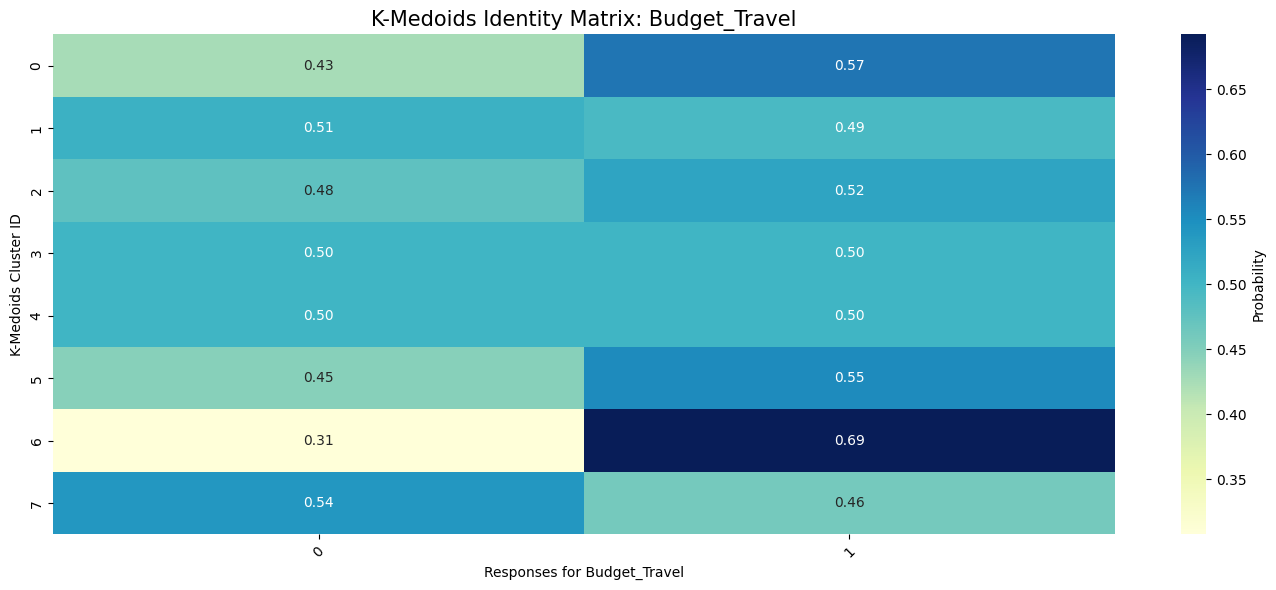

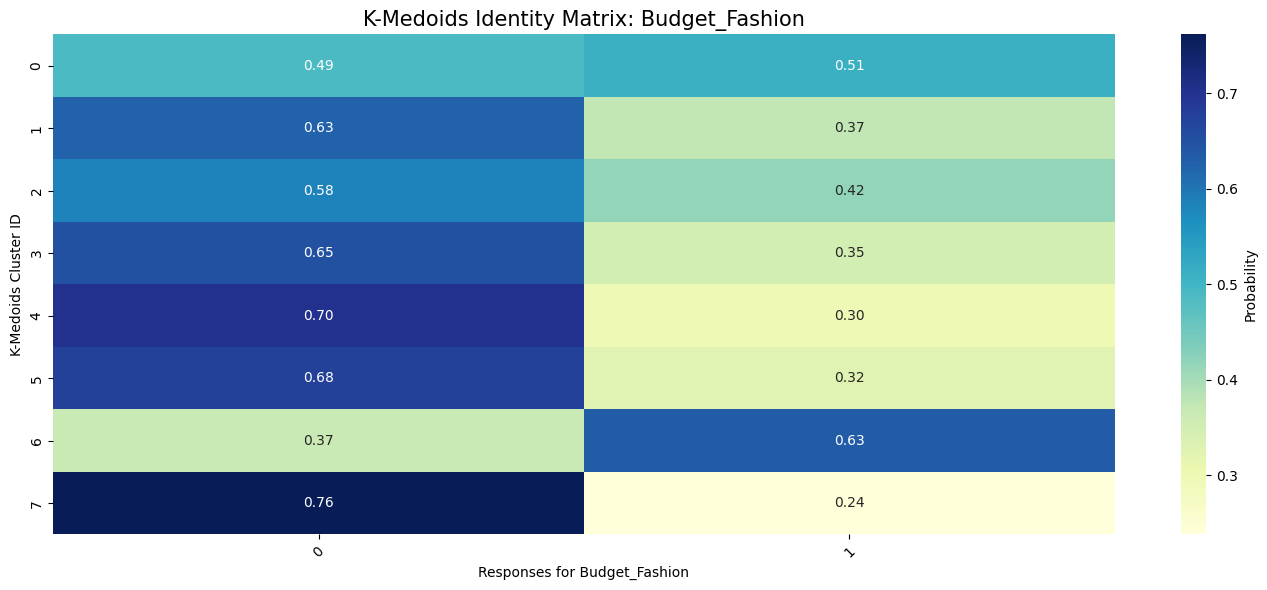

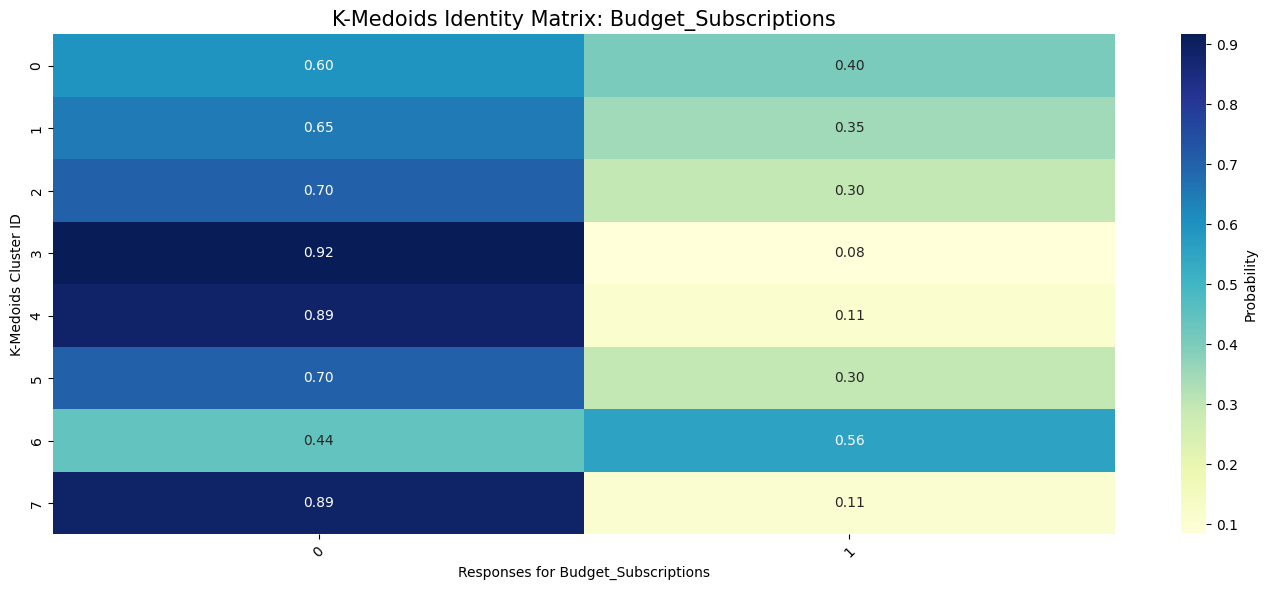

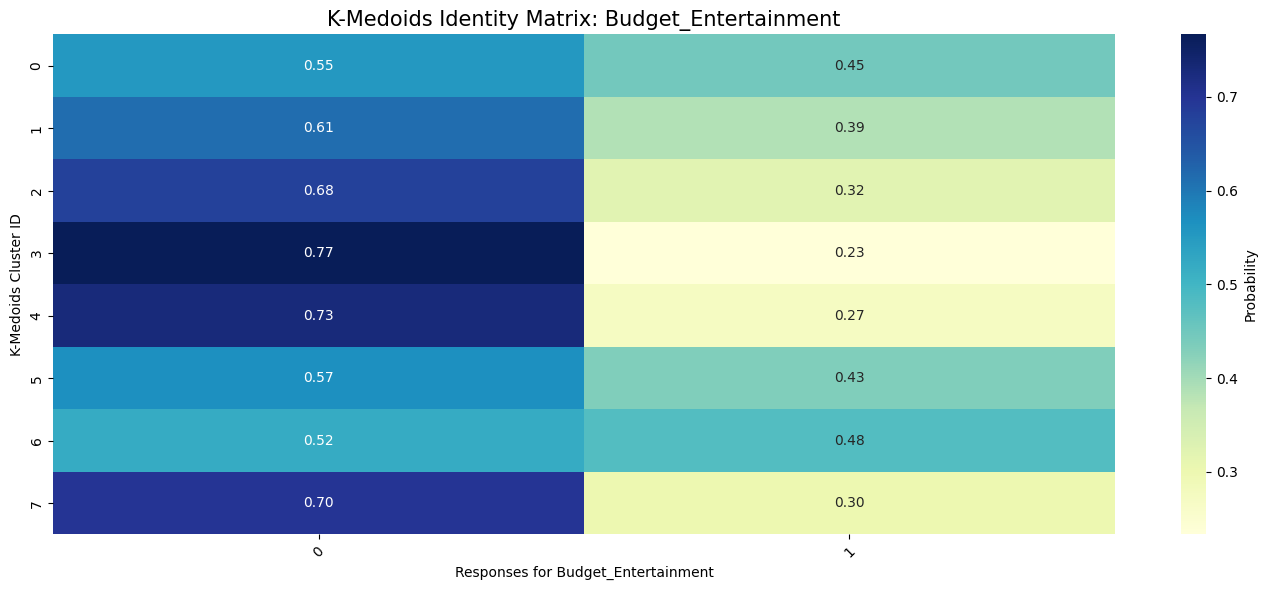

In [14]:
from pyclustering.cluster.kmedoids import kmedoids
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare data for pyclustering (list of lists)
# Using the same X_full you encoded earlier for PCA
X_list = data.drop(columns=['Group','Timestamp',"Group"], errors='ignore').values.tolist()

# Define your optimal K (from your 'best' marker in the previous run)
optimal_k = 8  # Replace with best_k from your evaluation

# 2. Initialize and Process
initial_medoids = np.random.choice(len(X_list), optimal_k, replace=False).tolist()
kmed_final = kmedoids(X_list, initial_medoids)
kmed_final.process()

# 3. Map clusters back to the DataFrame
clusters = kmed_final.get_clusters()
cluster_labels = np.zeros(len(data))

for cluster_id, indices in enumerate(clusters):
    for idx in indices:
        cluster_labels[idx] = cluster_id

data['KMedoids_Cluster'] = cluster_labels.astype(int)

# Select columns to visualize (excluding IDs and raw scores)
dna_cols = [col for col in data.columns if col not in 
            ['KMedoids_Cluster', 'Timestamp', 'Group', 'KMeans_Distance_Score', 
             'IForest_Anomaly_Score', 'RF_Weighted_Score']]

for col in dna_cols:
    # Check if column is categorical or has few unique values for readability
    if data[col].nunique() < 15: 
        # Create normalized cross-tab
        dna_matrix = pd.crosstab(data['KMedoids_Cluster'], data[col], normalize='index')
        
        plt.figure(figsize=(14, 6))
        sns.heatmap(dna_matrix, annot=True, cmap="YlGnBu", fmt=".2f", cbar_kws={'label': 'Probability'})
        
        plt.title(f"K-Medoids Identity Matrix: {col}", fontsize=15)
        plt.ylabel("K-Medoids Cluster ID")
        plt.xlabel(f"Responses for {col}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()